In [ ]:
!pip install Kaggle

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!mkdir ~/.kaggle
!cp /content/drive/MyDrive/kaggle/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download irustandi/yelp-review-polarity
!unzip yelp-review-polarity.zip

Dataset URL: https://www.kaggle.com/datasets/irustandi/yelp-review-polarity
License(s): unknown
 95% 307M/323M [00:00<00:00, 323MB/s]
100% 323M/323M [00:00<00:00, 392MB/s]
Archive:  yelp-review-polarity.zip
  inflating: yelp_review_polarity_csv/readme.txt  
  inflating: yelp_review_polarity_csv/test.csv  
  inflating: yelp_review_polarity_csv/train.csv  
  inflating: yelp_review_polarity_csv/yelp_review_polarity_csv/readme.txt  
  inflating: yelp_review_polarity_csv/yelp_review_polarity_csv/test.csv  
  inflating: yelp_review_polarity_csv/yelp_review_polarity_csv/train.csv  


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv('/content/yelp_review_polarity_csv/train.csv', header=None, names=['label', 'text'])

data['label'] = data['label'] - 1  # 1->0, 2->1

texts = data['text'].values
labels = data['label'].values

vocab_size = 20000
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

max_length = 250
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

x_train, x_val, y_train, y_val = train_test_split(padded_sequences, labels, test_size=0.2, random_state=47)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

class CustomLSTMCell(layers.Layer):
    def __init__(self, units):
        super(CustomLSTMCell, self).__init__()
        self.units = units

    def build(self, input_shape):
        self.W_i = self.add_weight(shape=(input_shape[-1], self.units), name='W_i')
        self.W_f = self.add_weight(shape=(input_shape[-1], self.units), name='W_f')
        self.W_c = self.add_weight(shape=(input_shape[-1], self.units), name='W_c')
        self.W_o = self.add_weight(shape=(input_shape[-1], self.units), name='W_o')

        self.U_i = self.add_weight(shape=(self.units, self.units), name='U_i')
        self.U_f = self.add_weight(shape=(self.units, self.units), name='U_f')
        self.U_c = self.add_weight(shape=(self.units, self.units), name='U_c')
        self.U_o = self.add_weight(shape=(self.units, self.units), name='U_o')

        self.b_i = self.add_weight(shape=(self.units,), name='b_i', initializer='zeros')
        self.b_f = self.add_weight(shape=(self.units,), name='b_f', initializer='zeros')
        self.b_c = self.add_weight(shape=(self.units,), name='b_c', initializer='zeros')
        self.b_o = self.add_weight(shape=(self.units,), name='b_o', initializer='zeros')

    def call(self, inputs, states):
        h_prev, c_prev = states

        i = tf.sigmoid(tf.matmul(inputs, self.W_i) + tf.matmul(h_prev, self.U_i) + self.b_i)
        f = tf.sigmoid(tf.matmul(inputs, self.W_f) + tf.matmul(h_prev, self.U_f) + self.b_f)
        c = tf.tanh(tf.matmul(inputs, self.W_c) + tf.matmul(h_prev, self.U_c) + self.b_c)
        o = tf.sigmoid(tf.matmul(inputs, self.W_o) + tf.matmul(h_prev, self.U_o) + self.b_o)

        c_new = f * c_prev + i * c
        h_new = o * tf.tanh(c_new)

        return h_new, [h_new, c_new]

    @property
    def state_size(self):
        return [self.units, self.units]

    @property
    def output_size(self):
        return self.units

In [ ]:
custom_lstm_cell = CustomLSTMCell(units=64)

vocab_size = 20000
embedding_dim = 128
max_len = 300

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    tf.keras.layers.RNN(custom_lstm_cell, return_sequences=True, return_state=False),
    tf.keras.layers.GlobalMaxPooling1D(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history = model.fit(x_train, y_train, epochs=5, batch_size=128, validation_data=(x_val, y_val))

model.summary()

loss, accuracy = model.evaluate(x_val, y_val)

print(f'Validation Accuracy: {accuracy:.4f}')

Epoch 1/5
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 176s 48ms/step - accuracy: 0.9018 - loss: 0.2343 - val_accuracy: 0.9488 - val_loss: 0.1320
Epoch 2/5
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 199s 48ms/step - accuracy: 0.9590 - loss: 0.1098 - val_accuracy: 0.9505 - val_loss: 0.1287
Epoch 3/5
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 191s 45ms/step - accuracy: 0.9720 - loss: 0.0789 - val_accuracy: 0.9538 - val_loss: 0.1212
Epoch 4/5
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 159s 45ms/step - accuracy: 0.9813 - loss: 0.0559 - val_accuracy: 0.9513 - val_loss: 0.1361
Epoch 5/5
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 202s 45ms/step - accuracy: 0.9877 - loss: 0.0385 - val_accuracy: 0.9495 - val_loss: 0.1598


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (128, 250, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (RNN)                       │ (128, 250, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (128, 64)              │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (128, 1)               │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,828,421 (29.86 MB)

 Trainable params: 2,609,473 (9.95 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,218,948 (19.91 MB)

3500/3500 ━━━━━━━━━━━━━━━━━━━━ 48s 14ms/step - accuracy: 0.9494 - loss: 0.1615
Validation Accuracy: 0.9495


In [ ]:
test_data = pd.read_csv('/content/yelp_review_polarity_csv/test.csv', header=None, names=['label', 'text'])
test_data['label'] = test_data['label'] - 1  # 1->0, 2->1

test_sequences = tokenizer.texts_to_sequences(test_data['text'].values)
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')
test_labels = test_data['label'].values

test_loss, test_accuracy = model.evaluate(test_padded, test_labels)

print(f'Test Accuracy: {test_accuracy:.4f}')

1188/1188 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9504 - loss: 0.1590
Test Accuracy: 0.9518


In [ ]:
model.save("/content/drive/MyDrive/Colab Notebooks/lstm.keras")

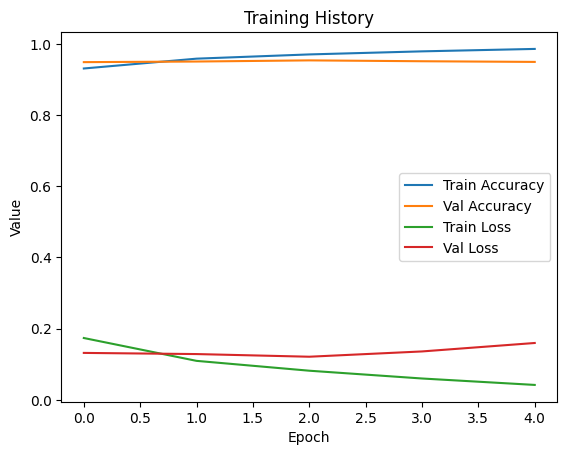

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training History')
plt.show()

In [ ]:
sample_texts = [
    "This restaurant was absolutely amazing! The food was delicious and the staff was super friendly. I highly recommend it!",
    "This place was terrible. The food was cold and the service was awful. I would never go back.",
    "The food was okay, some dishes were good, but others were not so great. The service was a bit slow."
]

sample_seqs = tokenizer.texts_to_sequences(sample_texts)
sample_padded = pad_sequences(sample_seqs, maxlen=max_length, padding='post', truncating='post')

predictions = model.predict(sample_padded)

for i, text in enumerate(sample_texts):
    prediction = predictions[i][0]
    sentiment = "позитивний" if prediction > 0.5 else "негативний"
    print(f"Речення: '{text}' - Прогнозована ймовірність позитивного відгуку: {prediction:.4f} ({sentiment})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 727ms/step
Речення: 'This restaurant was absolutely amazing! The food was delicious and the staff was super friendly. I highly recommend it!' - Прогнозована ймовірність позитивного відгуку: 1.0000 (позитивний)
Речення: 'This place was terrible. The food was cold and the service was awful. I would never go back.' - Прогнозована ймовірність позитивного відгуку: 0.0000 (негативний)
Речення: 'The food was okay, some dishes were good, but others were not so great. The service was a bit slow.' - Прогнозована ймовірність позитивного відгуку: 0.0015 (негативний)
